# Compatibility of clustering approaches



- How can I prove that my consensus and event detection heuristics work --> compatibility clustering, count moments when we have to decide ambiguities (statistic how often it happens), count events with ambiguopus context, count events where we don't know which partner to pick for translocation

In [1]:
# set working directory to project folder
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go

import plotly.io as pio
pio.renderers.default = "browser" 

import altair as alt
from itertools import combinations
import numpy as np
import math
import pypangraph as pp
from Bio import Phylo, SeqIO, AlignIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord

import random
import plotly.graph_objects as go
import plotly.express as px

from sklearn.metrics import adjusted_mutual_info_score
import scipy.cluster.hierarchy as sch
from collections import defaultdict, deque, Counter
from Bio import Phylo

from pathlib import Path
import subprocess

from Bio.Phylo.TreeConstruction import DistanceCalculator
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

from junction_analysis.helpers import get_tree_order, cluster_by_tree, strip_newick_suffixes, write_shared_nodes_fasta, simplify_cluster_keys, count_trna_per_junction, get_core_alignment_lengths, summarize_clustering_thresholds, compute_within_between_cluster_distances, add_silhouette_scores
from junction_analysis.junction_trees import build_tree_from_block_list, compute_pairwise_distances, cluster_tree_by_branch_length
import junction_analysis.pangraph_utils as pu
from junction_analysis.plotting import plot_all_junctions_pairwise_distances, plot_junction_heatmap, plot_clustering_threshold_sweep, plot_all_junctions_pairwise_distances_zoom, plot_score_threshold_violin, plot_core_alignment_lengths, plot_ambiguous_block_distances
from junction_analysis.consensus import find_consensus_paths, make_deduplicated_paths, consensus_paths_and_assignments, find_consensus_paths_core, cluster_map_to_dataframe, collect_all_pairwise_distances, save_consensus_cache, collect_all_branch_lengths, fitch_parsimony_steps_per_cluster
from junction_analysis.block_alignment import create_block_msas, summarize_block_msas, analyze_alignment, cluster_alignment, retrieve_cluster_assignments
from junction_analysis.annotate_insertions import get_insertions_deletions_from_consensus, write_insertions_fasta, summarize_deletions_consensus, load_all_deletions_summaries, summarize_inversions_consensus, summarize_translocations_consensus, write_insertions_fasta, load_all_insertions_summaries, load_all_inversions_summaries, load_all_translocations_summaries, combine_all_junctions_summaries, count_events_per_junction, deduplicate_events

### Block ambiguities for consensus reconstruction
- number doesn't change much at different thresholds
- they happen in clusters of different sizes
- no clean cutoff exists
- 3.4% of blocks are ambiguous (283), they are part of 21 junctions (3.8 % of all junctions)
- 29.7 % of ambiguous blocks appear only once and are assumed to be gains.
- 46.3 % of ambiguous blocks have high sequence similarity and are assumed to be lost.
- 24.0 % of ambiguous blocks have low sequence similarity and are assumed to be independent gains.

In [2]:
ambiguous_blocks_dfs = []

thresholds = ['05', '1', '2', '3', '4', '5', '6']
for thresh in thresholds:
    path = f"../results/consensus_analysis/ambiguous_blocks_000{thresh}.csv"
    ambiguous_blocks_df = pd.read_csv(path)
    ambiguous_blocks_dfs.append(ambiguous_blocks_df)
    print(f"Number of clusters with at least 1 ambiguos block {len(ambiguous_blocks_df[ambiguous_blocks_df['n_ambiguous'] > 0])}")
    print(f"Total number of ambiguous blocks: {ambiguous_blocks_df.n_ambiguous.sum()}")
    print(f"{ambiguous_blocks_df.n_single_isolate.sum()} of those are part of a single isolate and defaulted to gains.")
    print(f"{ambiguous_blocks_df.n_decided_gain.sum()} are not similar and likely to be independent gains.")
    print(f"{ambiguous_blocks_df.n_decided_loss.sum()} are quite similar and decided to be a loss.")
    print()

# doesn't change much depending on threshold

Number of clusters with at least 1 ambiguos block 26
Total number of ambiguous blocks: 276
84 of those are part of a single isolate and defaulted to gains.
66 are not similar and likely to be independent gains.
126 are quite similar and decided to be a loss.

Number of clusters with at least 1 ambiguos block 27
Total number of ambiguous blocks: 283
84 of those are part of a single isolate and defaulted to gains.
68 are not similar and likely to be independent gains.
131 are quite similar and decided to be a loss.

Number of clusters with at least 1 ambiguos block 28
Total number of ambiguous blocks: 287
88 of those are part of a single isolate and defaulted to gains.
67 are not similar and likely to be independent gains.
132 are quite similar and decided to be a loss.

Number of clusters with at least 1 ambiguos block 29
Total number of ambiguous blocks: 394
106 of those are part of a single isolate and defaulted to gains.
74 are not similar and likely to be independent gains.
214 are 

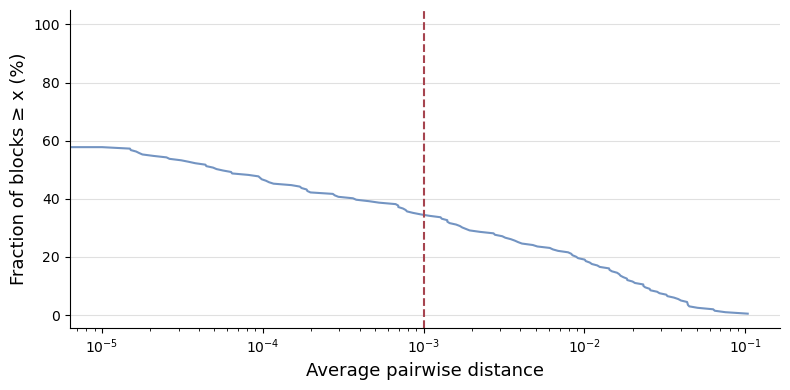

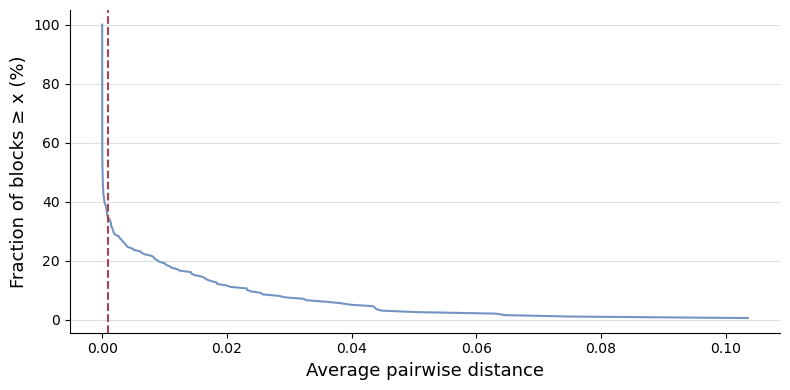

Percentage of ambiguous blocks out of all blocks: 3.4170490219753686
21 junctions contain ambiguities. This are 3.832116788321168 %.
29.681978798586574 % of ambiguous blocks appear only once and are assumed to be gains.
46.28975265017668 % of ambiguous blocks have high sequence similarity and are assumed to be lost.
24.02826855123675 % of ambiguous blocks have low sequence similarity and are assumed to be independent gains.


,junction_name,cluster_id,n_isolates_in_cluster,n_total_blocks,n_ambiguous,n_single_isolate,n_decided_loss,n_decided_gain,avg_pairwise_dists
9,JJRRWBDVGH_f__TFKJQKVUKX_f,0,212,103,4,0,2,2,"[np.float64(0.03829267202558178), np.float64(0..."
119,IOOFKXBSGN_f__JFTSMYGWDT_f,0,222,21,3,0,2,1,"[np.float64(0.0014037084459619668), np.float64..."
165,HEDBBNUKLU_r__VSCDQDGRHO_r,0,221,37,1,0,1,0,[np.float64(0.0)]
190,IMAMHFLCWS_f__RKAOKULCFF_f,0,221,16,1,0,0,1,[np.float64(0.003086734693877551)]
282,NOAJDCSIVA_f__NZXBIFMPMA_r,0,210,5,1,0,1,0,[np.float64(0.0005281127230240337)]
313,RKAOKULCFF_f__VFXLTFSKTV_r,0,188,28,9,0,9,0,"[np.float64(0.0), np.float64(0.0), np.float64(..."
358,LFZGFSBAPK_r__QRYVQHRCDP_f,0,222,21,12,0,12,0,"[np.float64(1.7857142857142862e-05), np.float6..."
391,LRPZIYPPND_r__VTCLZJNIFI_f,0,170,7,4,0,3,1,"[np.float64(0.0034841504714462975), np.float64..."
463,BRZJUAZYZF_f__NOAJDCSIVA_f,0,222,4,2,0,2,0,"[np.float64(0.0), np.float64(0.0)]"
519,CGQZOLYSTD_r__ZLLQQUXUIP_r,0,222,88,18,0,1,17,"[np.float64(0.01079030770823022), np.float64(0..."


In [20]:
# we continue with threshold that we started with

ambiguous_blocks_df = pd.read_csv("../results/consensus_analysis/ambiguous_blocks_0001.csv")

plot_ambiguous_block_distances(ambiguous_blocks_df, cumulative=True, log_x=True, vline=0.001)     
plot_ambiguous_block_distances(ambiguous_blocks_df, cumulative=True, log_x=False, vline=0.001)

n_ambiguous_blocks = ambiguous_blocks_df.n_ambiguous.sum()
n_single_isolate_blocks = ambiguous_blocks_df.n_single_isolate.sum()
n_decided_loss_blocks = ambiguous_blocks_df.n_decided_loss.sum()
n_decided_gain_blocks = ambiguous_blocks_df.n_decided_gain.sum()

print(f"Percentage of ambiguous blocks out of all blocks: {n_ambiguous_blocks / ambiguous_blocks_df.n_total_blocks.sum() * 100}")
print(f"{len(ambiguous_blocks_df[ambiguous_blocks_df['n_ambiguous'] > 0].junction_name.unique())} junctions contain ambiguities. This are {len(ambiguous_blocks_df[ambiguous_blocks_df['n_ambiguous'] > 0].junction_name.unique()) / 548 * 100} %.")
print(f"{n_single_isolate_blocks / n_ambiguous_blocks * 100} % of ambiguous blocks appear only once and are assumed to be gains.")
print(f"{n_decided_loss_blocks / n_ambiguous_blocks * 100} % of ambiguous blocks have high sequence similarity and are assumed to be lost.")
print(f"{n_decided_gain_blocks / n_ambiguous_blocks * 100} % of ambiguous blocks have low sequence similarity and are assumed to be independent gains.")

ambiguous_blocks_df[ambiguous_blocks_df['n_ambiguous'] > 0]

### Core block length distribution

Saved figure to ../figures/core_block_length_distr.pdf


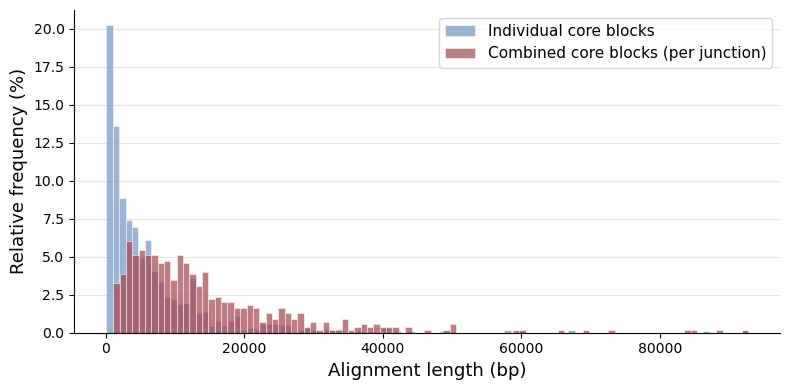

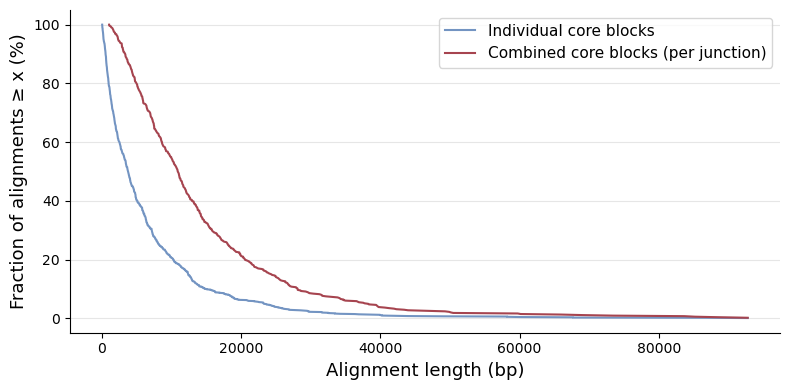

In [2]:
core_aln_length_df = pd.read_csv("../results/consensus_analysis/core_aln_lengths.csv")
core_block_aln_length_df = pd.read_csv("../results/consensus_analysis/core_block_aln_lengths.csv")

plot_core_alignment_lengths(core_aln_length_df, block_df=core_block_aln_length_df, col="aln_length_nogap", bins=100, cumulative=False, figsize=(8,4), save_path="../figures/core_block_length_distr.pdf")
plot_core_alignment_lengths(core_aln_length_df, block_df=core_block_aln_length_df, col="aln_length_nogap", cumulative=True, figsize=(8,4)) 

### Cluster consistency with core genome phylogeny

In [21]:
summary_rows = []
per_cluster_parsimony_dfs = []
tree_path = "../config/polished_tree.nwk"

for thresh in ['05', '1', '2', '3', '4', '5', '6']:
    cluster_df = pd.read_csv(f"../results/consensus_analysis/cluster_maps_0_00{thresh}.csv")

    per_cluster_parsimony_df = fitch_parsimony_steps_per_cluster(
        cluster_df,
        tree_path,
        junction_col="junction_name",
        save_path=f"../results/consensus_analysis/parsimonious_clusters_000{thresh}.csv"
    )
    per_cluster_parsimony_dfs.append(per_cluster_parsimony_df)

    print(per_cluster_parsimony_df.value_counts('n_parsimony_steps'))
    print(f"{len(per_cluster_parsimony_df[per_cluster_parsimony_df['n_parsimony_steps'] > 1]) / len(per_cluster_parsimony_df[per_cluster_parsimony_df['n_clusters'] > 1])} % of clusters were not consistent with the tree (excluding junctions with no clusters)")

    # only junctions with more than one cluster
    multi_cluster_df = per_cluster_parsimony_df[per_cluster_parsimony_df["n_clusters"] > 1].copy()
    n_clusters_not_consistent = (multi_cluster_df["n_parsimony_steps"] > 1).sum()
    bad_junctions = multi_cluster_df.loc[multi_cluster_df["n_parsimony_steps"] > 1, "junction_name"].nunique()

    # total number of clusters in junctions with > 1 cluster
    n_clusters_in_multi_cluster_junctions = len(multi_cluster_df)

    summary_rows.append({
        "threshold": float(f"0.00{thresh}"),
        "n_clusters_not_consistent_with_tree": n_clusters_not_consistent,
        "n_junctions_not_consistent_with_tree": bad_junctions,
        "n_clusters_in_junctions_with_more_than_one_cluster": n_clusters_in_multi_cluster_junctions,
    })

summary_df = pd.DataFrame(summary_rows).sort_values("threshold").reset_index(drop=True)
print(summary_df)

Saved parsimony steps to ../results/consensus_analysis/parsimonious_clusters_00005.csv
n_parsimony_steps
0     778
1     271
2      13
4       1
26      1
Name: count, dtype: int64
0.019255455712451863 % of clusters were not consistent with the tree (excluding junctions with no clusters)
Saved parsimony steps to ../results/consensus_analysis/parsimonious_clusters_0001.csv
n_parsimony_steps
0    759
1    156
2     11
Name: count, dtype: int64
0.018333333333333333 % of clusters were not consistent with the tree (excluding junctions with no clusters)
Saved parsimony steps to ../results/consensus_analysis/parsimonious_clusters_0002.csv
n_parsimony_steps
0    714
1    149
2     12
Name: count, dtype: int64
0.023529411764705882 % of clusters were not consistent with the tree (excluding junctions with no clusters)
Saved parsimony steps to ../results/consensus_analysis/parsimonious_clusters_0003.csv
n_parsimony_steps
0    679
1    139
2     13
Name: count, dtype: int64
0.02981651376146789 % of

In [22]:
per_cluster_parsimony_dfs[1][per_cluster_parsimony_dfs[1]['n_parsimony_steps'] > 1]
#per_cluster_parsimony_dfs[1][per_cluster_parsimony_dfs[1]['n_parsimony_steps'] > 1].junction_name.unique()

,junction_name,n_isolates,n_clusters,cluster_id,n_isolates_in_cluster,n_parsimony_steps
32,ITEMFVYTUE_r__JVDYVQZUBR_r,222,7,0,160,2
89,SFNIQHXIST_f__YSKQIEWBCG_f,222,5,0,149,2
95,SFNIQHXIST_r__TJOBMLQRFA_r,222,5,0,149,2
233,OBEJYXNUDN_r__ZTHKZYHPIX_r,222,6,0,149,2
257,OBEJYXNUDN_f__TJOBMLQRFA_f,222,6,0,149,2
442,GXPNFHPAJW_f__ZEWJRLKRRP_f,222,6,4,121,2
742,DGMGBEYIHM_r__GXPNFHPAJW_f,222,8,0,159,2
750,DGMGBEYIHM_f__JVDYVQZUBR_f,222,8,0,159,2
768,VZOKOXMBEZ_f__ZEWJRLKRRP_r,222,5,0,157,2
832,VZOKOXMBEZ_r__YUOECYBHUS_f,222,9,0,154,2


In [24]:
n_junctions_with_inconsistency = len(per_cluster_parsimony_dfs[1][per_cluster_parsimony_dfs[1]['n_parsimony_steps'] > 1].junction_name.unique())
print(f"{n_junctions_with_inconsistency} junctions contain 1 inconsistant cluster. These are {n_junctions_with_inconsistency / 548 * 100} % of junctions.")

11 junctions contain 1 inconsistant cluster. These are 2.0072992700729926 % of junctions.


In [28]:
n_cluster_with_inconsistency = len(per_cluster_parsimony_dfs[1][per_cluster_parsimony_dfs[1]['n_parsimony_steps'] > 1]) 
n_cluster_in_clustered_junctions = per_cluster_parsimony_dfs[1][per_cluster_parsimony_dfs[1]['n_clusters'] > 1].n_clusters.sum()
print(f"{n_cluster_with_inconsistency} cluster are not consistent with the tree. These are {n_cluster_with_inconsistency / n_cluster_in_clustered_junctions * 100} % of potentially inconsistent clusters.")

11 cluster are not consistent with the tree. These are 0.5188679245283019 % of potentially inconsistent clusters.


### Branch length cutoff via cumulative distribution of branch lengths

Saved branch lengths to ../results/consensus_analysis/branch_lengths.csv.


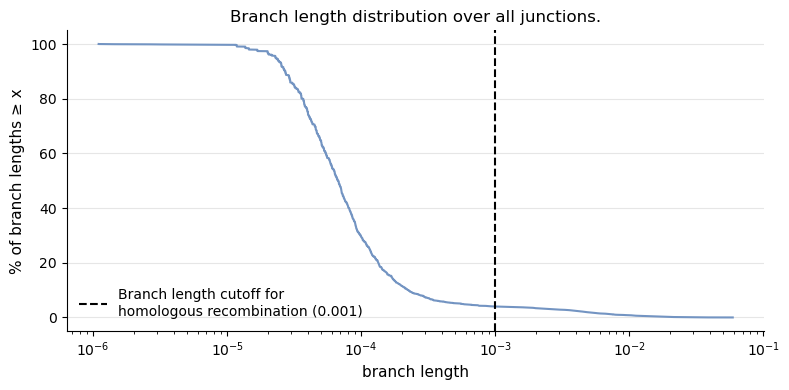

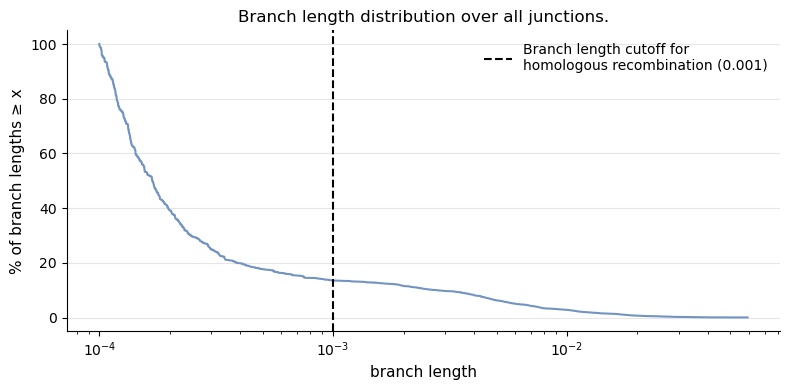

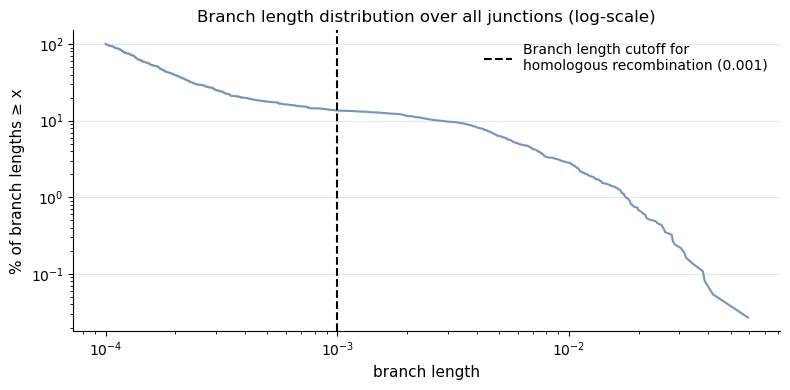

In [2]:
branch_df = collect_all_branch_lengths("../results/", save_path="../results/consensus_analysis/branch_lengths.csv")
bl_cutoff = 0.001
plot_all_junctions_pairwise_distances(branch_df[branch_df['branch_length']>1e-8], distance_col = "branch_length", cumulative=True, log_x = True, log_y = False, vline=bl_cutoff, percentage=True, title="Branch length distribution over all junctions.", figsize=(8,4), xlabel='branch length', ylabel = "% of branch lengths ≥ x", legend_title=f"Branch length cutoff for \nhomologous recombination ({bl_cutoff})")
plot_all_junctions_pairwise_distances(branch_df[branch_df['branch_length']>1e-4], distance_col = "branch_length", cumulative=True, log_x = True, log_y = False, vline=bl_cutoff, percentage=True, title="Branch length distribution over all junctions.", figsize=(8,4), xlabel='branch length', ylabel = "% of branch lengths ≥ x", legend_title=f"Branch length cutoff for \nhomologous recombination ({bl_cutoff})")
plot_all_junctions_pairwise_distances(branch_df[branch_df['branch_length']>1e-4], distance_col = "branch_length", cumulative=True, log_x = True, log_y = True, vline=bl_cutoff, percentage=True, title="Branch length distribution over all junctions (log-scale)", figsize=(8,4), xlabel='branch length', ylabel = "% of branch lengths ≥ x", legend_title=f"Branch length cutoff for \nhomologous recombination ({bl_cutoff})")

/Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/junction_analysis/plotting.py:4028: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



Saved figure to ../figures/branch_length_cutoff.pdf


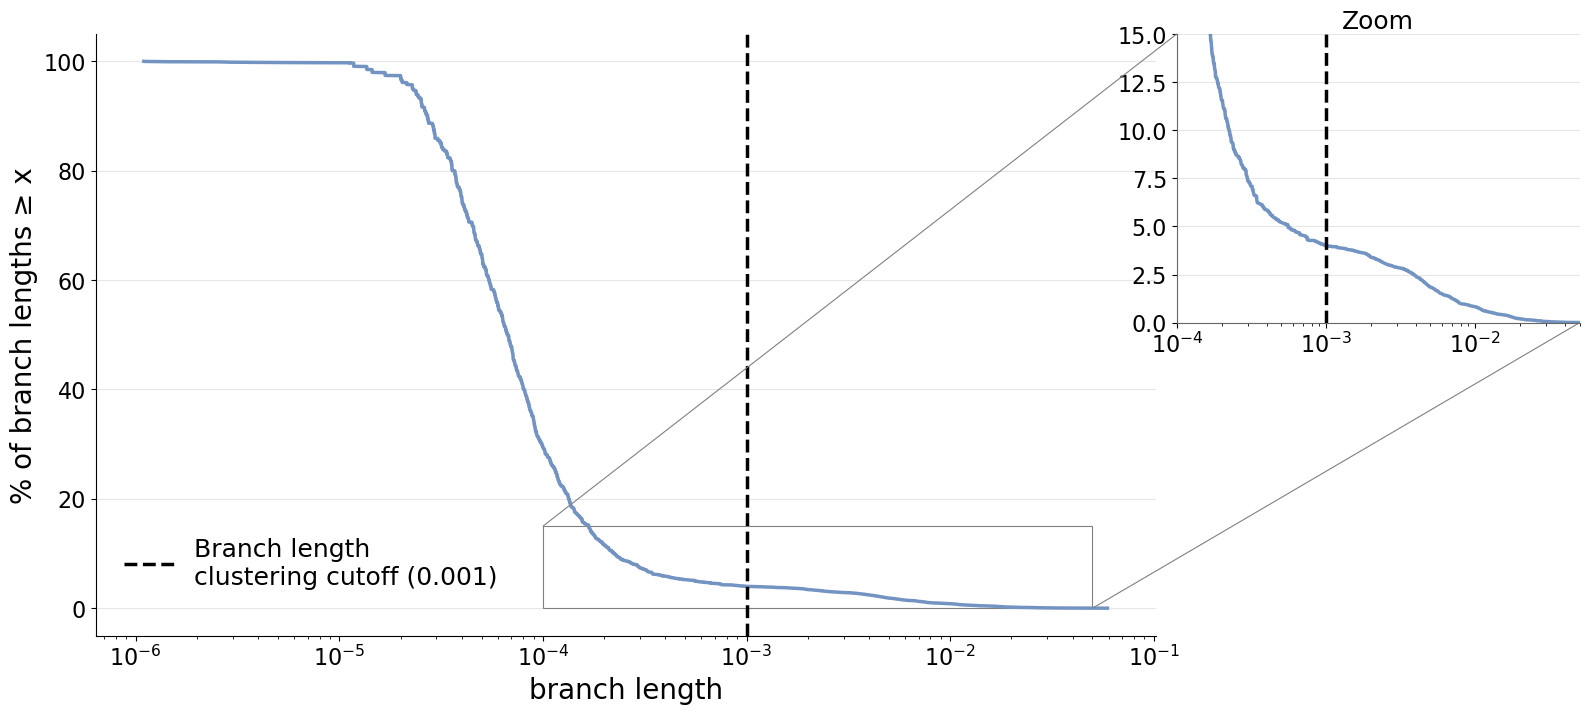

In [3]:
plot_all_junctions_pairwise_distances_zoom(
    distances_df=branch_df[branch_df['branch_length']>1e-8],
    distance_col='branch_length',
    cumulative=True,
    percentage=True,
    log_x=True,
    vline=1e-3,
    figsize=(12, 7),
    title="",
    xlabel="branch length",
    ylabel="% of branch lengths ≥ x",
    legend_title="Branch length \nclustering cutoff (0.001)",
    zoom_xlim=(1e-4, 5e-2),
    zoom_ylim=(0, 15),
    save_path="../figures/branch_length_cutoff.pdf"
)

In [4]:
alignment_dist_df = pd.read_csv("../results/consensus_analysis/pairwise_rel_hamming_dist.csv")

block_edge_dist = pd.read_csv("../results/consensus_analysis/pairwise_dedup_ji.csv")

block_dist_df = block_edge_dist.copy().loc[:, ['junction_name', 'isolate_1', 'isolate_2', 'block_ji_dist']]
block_dist_df.rename(columns={'block_ji_dist': 'distance'}, inplace=True)

edge_dist_df = block_edge_dist.copy().loc[:, ['junction_name', 'isolate_1', 'isolate_2', 'edge_ji_dist']]
edge_dist_df.rename(columns={'edge_ji_dist': 'distance'}, inplace=True)

In [ ]:
for thresh in ['05', '1', '2', '3', '4', '5', '6']:
    print(thresh)
    cluster_df = pd.read_csv(f"../results/consensus_analysis/cluster_maps_0_00{thresh}.csv")
    wb_cluster_dist = compute_within_between_cluster_distances(cluster_df, alignment_dist_df, save_path=f'../results/consensus_analysis/cluster_pairwise_dist_000{thresh}.csv')

for thresh in ['05', '1', '2', '3', '4', '5', '6']:
    print(thresh)
    cluster_df = pd.read_csv(f"../results/consensus_analysis/cluster_maps_0_00{thresh}.csv")
    wb_cluster_dist = compute_within_between_cluster_distances(cluster_df, block_dist_df, save_path=f'../results/consensus_analysis/cluster_block_ji_000{thresh}.csv')

for thresh in ['05', '1', '2', '3', '4', '5', '6']:
    print(thresh)
    cluster_df = pd.read_csv(f"../results/consensus_analysis/cluster_maps_0_00{thresh}.csv")
    wb_cluster_dist = compute_within_between_cluster_distances(cluster_df, edge_dist_df, save_path=f'../results/consensus_analysis/cluster_edge_ji_000{thresh}.csv')

# 100 min

In [14]:
core_pairwise_paths = [f"../results/consensus_analysis/cluster_pairwise_dist_000{thresh}.csv" for thresh in ['05', '1', '2', '3', '4', '5', '6']]
block_paths = [f"../results/consensus_analysis/cluster_block_ji_000{thresh}.csv" for thresh in ['05', '1', '2', '3', '4', '5', '6']]
edge_paths = [f"../results/consensus_analysis/cluster_edge_ji_000{thresh}.csv" for thresh in ['05', '1', '2', '3', '4', '5', '6']]

# maybe need to compare clustering between junctions that have clusters in all cases but more or less, this is done now
cluster_df = pd.read_csv(f"../results/consensus_analysis/cluster_maps_0_006.csv")
clustering_exists = cluster_df[cluster_df['n_clusters'] > 1].junction_name.to_list()

wb_core_pairwise_dfs = []
wb_block_dfs = []
wb_edge_dfs = []

for path in core_pairwise_paths:
    wb_diff_df = pd.read_csv(path)
    #wb_diff_df = wb_diff_df[wb_diff_df["n_clusters"] > 1]
    wb_diff_df = wb_diff_df[wb_diff_df["junction_name"].isin(clustering_exists)]
    wb_diff_df = add_silhouette_scores(wb_diff_df, within_col = 'mean_within_dist', between_col='mean_between_dist', is_similarity=False)
    wb_core_pairwise_dfs.append(wb_diff_df)

for path in block_paths:
    wb_diff_df = pd.read_csv(path)
    #wb_diff_df = wb_diff_df[wb_diff_df["n_clusters"] > 1]
    wb_diff_df = wb_diff_df[wb_diff_df["junction_name"].isin(clustering_exists)]
    wb_diff_df = add_silhouette_scores(wb_diff_df, within_col = 'mean_within_dist', between_col='mean_between_dist', is_similarity=True)
    wb_block_dfs.append(wb_diff_df)

for path in edge_paths:
    wb_diff_df = pd.read_csv(path)
    #wb_diff_df = wb_diff_df[wb_diff_df["n_clusters"] > 1]
    wb_diff_df = wb_diff_df[wb_diff_df["junction_name"].isin(clustering_exists)]
    wb_diff_df = add_silhouette_scores(wb_diff_df, within_col = 'mean_within_dist', between_col='mean_between_dist', is_similarity=True)
    wb_edge_dfs.append(wb_diff_df)

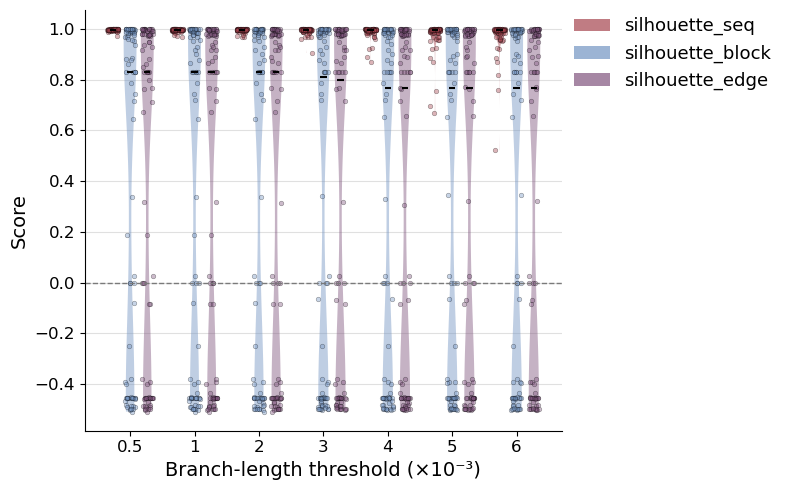

Saved figure to ../figures/silhouette_block_edge_ji.pdf


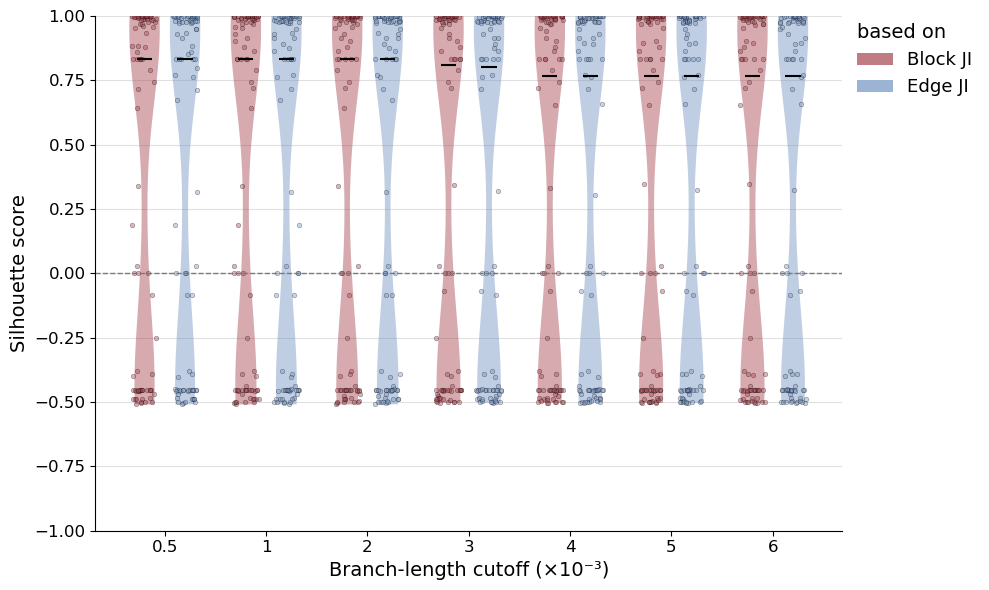

In [15]:
combined_dfs = [
      core.rename(columns={"silhouette_score": "silhouette_seq"})[["junction_name", "silhouette_seq"]]
      .merge(block.rename(columns={"silhouette_score": "silhouette_block"})[["junction_name", "silhouette_block"]], on="junction_name", how="outer")                                                        
      .merge(edge.rename(columns={"silhouette_score": "silhouette_edge"})[["junction_name", "silhouette_edge"]], on="junction_name", how="outer")
      for core, block, edge in zip(wb_core_pairwise_dfs, wb_block_dfs, wb_edge_dfs)                                                                                                                         
  ]
plot_score_threshold_violin(combined_dfs, thresholds=[0.0005, 0.001, 0.002, 0.003, 0.004, 0.005, 0.006],
      score_col=["silhouette_seq", "silhouette_block", "silhouette_edge"])

plot_score_threshold_violin(combined_dfs, thresholds=[0.0005, 0.001, 0.002, 0.003, 0.004, 0.005, 0.006],
      score_col=["silhouette_block", "silhouette_edge"], ylim = (-1,1), figsize=(10,6), xlabel = "Branch-length cutoff" , ylabel = "Silhouette score", legend_labels=["Block JI", "Edge JI"], legend_title = "based on", save_path = "../figures/silhouette_block_edge_ji.pdf")

In [ ]:
# general jaccard index per junction

In [19]:
df = combined_dfs[0]
df

,junction_name,silhouette_seq,silhouette_block,silhouette_edge
0,AFFODHUCNW_f__KDNDVPYXTO_f,0.997284,-0.453846,-0.453846
1,AFFODHUCNW_r__VRDEBAMMSO_r,0.997234,0.968557,0.949664
2,AVUIDSRMNP_r__WCJONKLHBM_r,0.996288,-0.453846,-0.453846
3,AVXTXOCVMG_f__WOHPWXHUSI_r,0.999531,-0.489744,-0.489744
4,AVXTXOCVMG_r__GBIULQMJVJ_f,0.990671,0.967505,0.974486
...,...,...,...,...
81,VRDEBAMMSO_r__WXCHSHHCDT_r,0.996242,0.978332,0.978332
82,VZOKOXMBEZ_f__ZEWJRLKRRP_r,0.998727,0.881848,0.881709
83,VZOKOXMBEZ_r__YUOECYBHUS_f,0.999332,0.000000,0.000000
84,WOABSWWVRB_r__YNFGSNJILT_r,0.996670,-0.379287,-0.379354


In [22]:
for df in combined_dfs:
    print(f"median block_silhouette: {df.silhouette_block.median()}")
    print(f"median edge_silhouette: {df.silhouette_edge.median()}")

median block_silhouette: 0.8309859154929734
median edge_silhouette: 0.8309859154929503
median block_silhouette: 0.8309859154929664
median edge_silhouette: 0.8309859154929503
median block_silhouette: 0.8309859154929664
median edge_silhouette: 0.8309859154929503
median block_silhouette: 0.8096928291974312
median edge_silhouette: 0.8003098730080613
median block_silhouette: 0.7659646789456269
median edge_silhouette: 0.7661511594735342
median block_silhouette: 0.7666655032201806
median edge_silhouette: 0.7661576936263161
median block_silhouette: 0.7669143420342699
median edge_silhouette: 0.7663989038752554


Saved figure to ../figures/silhouette_junction_complexity.pdf


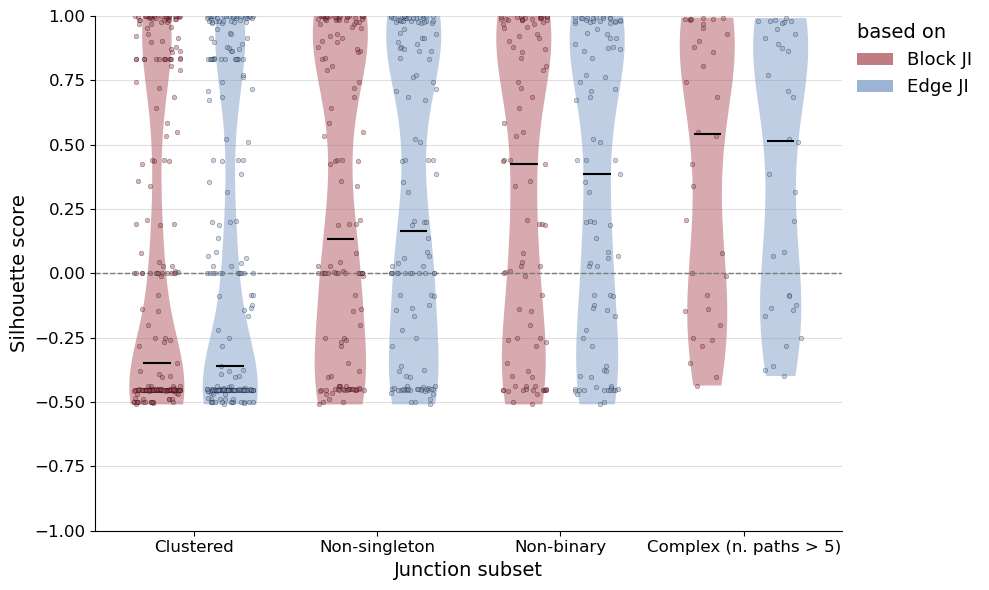

In [9]:
# load only threshold 0.001            
core_df_001 = pd.read_csv("../results/consensus_analysis/cluster_pairwise_dist_0001.csv")
block_df_001 = pd.read_csv("../results/consensus_analysis/cluster_block_ji_0001.csv")                                                                                                                     
edge_df_001 = pd.read_csv("../results/consensus_analysis/cluster_edge_ji_0001.csv")
                                                                                                                                                                                                        
# filtering lists
_fname = f"../config/junction_stats.csv"
jdf = pd.read_csv(_fname)
non_singletons = jdf[jdf['singleton'] == False].edge.to_list()
non_binary = jdf[jdf['n_categories'] > 2].edge.to_list()
complex_junctions = jdf[jdf['n_categories'] > 5].edge.to_list()
cluster_df = pd.read_csv(f"../results/consensus_analysis/cluster_maps_0_001.csv")
clustering_exists = cluster_df[cluster_df['n_clusters'] > 1].junction_name.to_list()


filter_sets = {
    "Clustered":      clustering_exists,
    "Non-singleton":     [j for j in clustering_exists if j in non_singletons],
    "Non-binary":         [j for j in clustering_exists if j in non_binary],
    "Complex (n. paths > 5)":   [j for j in clustering_exists if j in complex_junctions],
}

def make_combined_df(junctions):
    def prep(df, score_col_name, is_similarity):
        d = df[df["junction_name"].isin(junctions)].copy()
        d = add_silhouette_scores(d, within_col='mean_within_dist', between_col='mean_between_dist', is_similarity=is_similarity)
        return d.rename(columns={"silhouette_score": score_col_name})[["junction_name", score_col_name]]
    core  = prep(core_df_001,  "silhouette_seq",   is_similarity=False)
    block = prep(block_df_001, "silhouette_block",  is_similarity=True)
    edge  = prep(edge_df_001,  "silhouette_edge",   is_similarity=True)
    return core.merge(block, on="junction_name", how="outer").merge(edge, on="junction_name", how="outer")

filter_dfs = [make_combined_df(junctions) for junctions in filter_sets.values()]

plot_score_threshold_violin(
    filter_dfs,
    thresholds=list(filter_sets.keys()),
    score_col=["silhouette_block", "silhouette_edge"],
    ylim=(-1, 1),
    figsize=(10, 6),
    xlabel="Junction subset",
    ylabel="Silhouette score",
    legend_labels=["Block JI", "Edge JI"],
    legend_title="based on",
    save_path="../figures/silhouette_junction_complexity.pdf"
)


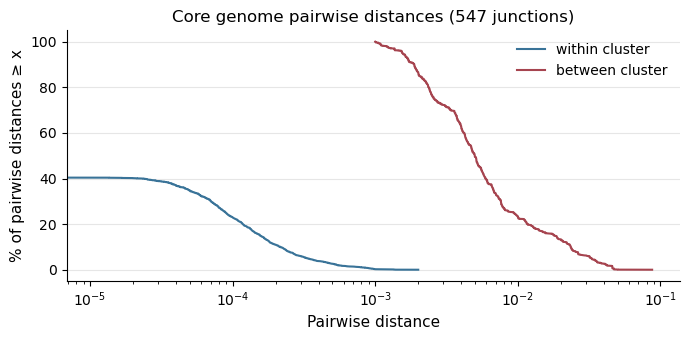

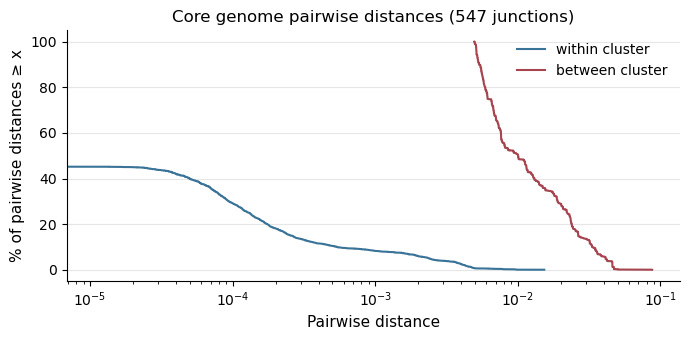

In [10]:
cluster_df = pd.read_csv(f"../results/consensus_analysis/cluster_maps_0_001.csv")
plot_all_junctions_pairwise_distances(                                                                                                                                                                    
      alignment_dist_df,                                                                                                                                                                                  
      cumulative=True,
      percentage=True,
      log_x=True,
      cluster_df=cluster_df,
      vline=None,
      xlabel="Pairwise distance",
      ylabel="% of pairwise distances ≥ x",
  )

cluster_df = pd.read_csv(f"../results/consensus_analysis/cluster_maps_0_005.csv")
plot_all_junctions_pairwise_distances(                                                                                                                                                                    
      alignment_dist_df,                                                                                                                                                                                  
      cumulative=True,
      percentage=True,
      log_x=True,
      cluster_df=cluster_df,
      vline=None,
      xlabel="Pairwise distance",
      ylabel="% of pairwise distances ≥ x",
  )

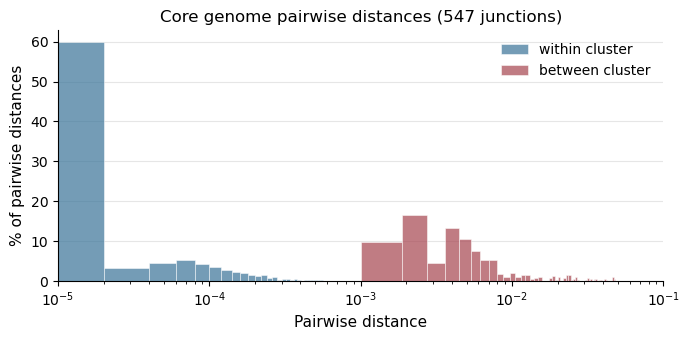

In [11]:
cluster_df = pd.read_csv(f"../results/consensus_analysis/cluster_maps_0_001.csv")

plot_all_junctions_pairwise_distances(                                                                                                                                                                    
      alignment_dist_df,                                                                                                                                                                                  
      cumulative=False,
      percentage=True,
      log_x=True,
      cluster_df=cluster_df,
      vline=None,
      xlabel="Pairwise distance",
      xlim =(1e-5, 1e-1),
      ylabel="% of pairwise distances",
  )

# they add up to 100% on their own, not combined

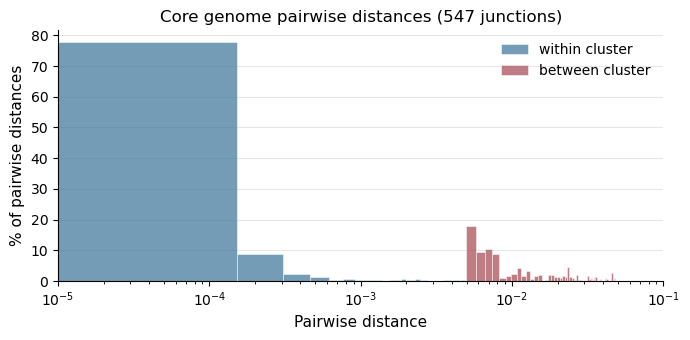

In [12]:
cluster_df = pd.read_csv(f"../results/consensus_analysis/cluster_maps_0_005.csv")

plot_all_junctions_pairwise_distances(                                                                                                                                                                    
      alignment_dist_df,                                                                                                                                                                                  
      cumulative=False,
      percentage=True,
      log_x=True,
      cluster_df=cluster_df,
      vline=None,
      xlabel="Pairwise distance",
      xlim =(1e-5, 1e-1),
      ylabel="% of pairwise distances",
  )

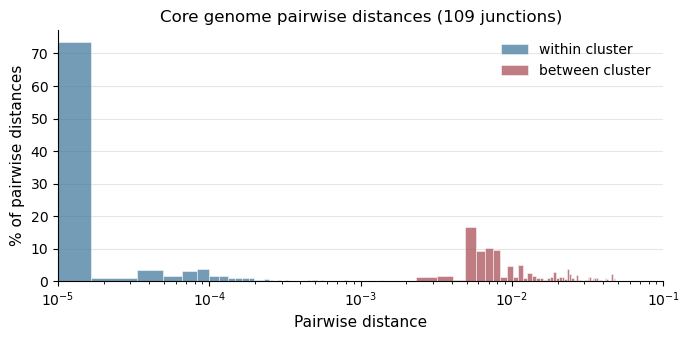

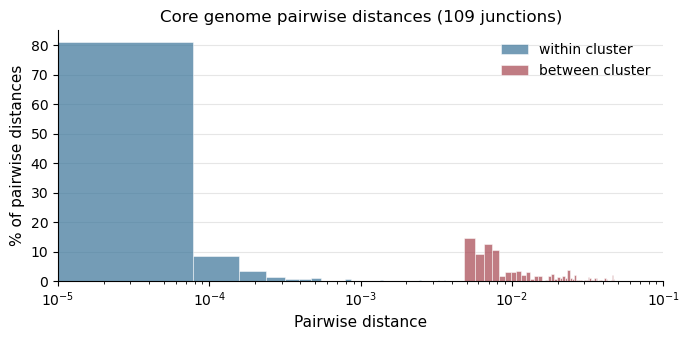

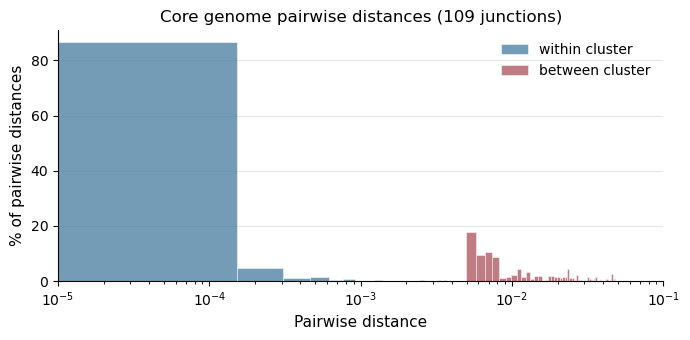

In [13]:
# maybe need to compare clustering between junctions that have clusters in all cases but more or less, this is done now
cluster_df = pd.read_csv(f"../results/consensus_analysis/cluster_maps_0_005.csv")
clustering_exists = cluster_df[cluster_df['n_clusters'] > 1].junction_name.to_list()

cluster_df = pd.read_csv(f"../results/consensus_analysis/cluster_maps_0_001.csv")

plot_all_junctions_pairwise_distances(                                                                                                                                                                    
      alignment_dist_df[alignment_dist_df['junction_name'].isin(clustering_exists)],                                                                                                                                                                                  
      cumulative=False,
      percentage=True,
      log_x=True,
      cluster_df=cluster_df,
      vline=None,
      xlabel="Pairwise distance",
      xlim =(1e-5, 1e-1),
      ylabel="% of pairwise distances",
  )

cluster_df = pd.read_csv(f"../results/consensus_analysis/cluster_maps_0_003.csv")

plot_all_junctions_pairwise_distances(                                                                                                                                                                    
      alignment_dist_df[alignment_dist_df['junction_name'].isin(clustering_exists)],                                                                                                                                                                                  
      cumulative=False,
      percentage=True,
      log_x=True,
      cluster_df=cluster_df,
      vline=None,
      xlabel="Pairwise distance",
      xlim =(1e-5, 1e-1),
      ylabel="% of pairwise distances",
  )

cluster_df = pd.read_csv(f"../results/consensus_analysis/cluster_maps_0_005.csv")

plot_all_junctions_pairwise_distances(                                                                                                                                                                    
      alignment_dist_df[alignment_dist_df['junction_name'].isin(clustering_exists)],                                                                                                                                                                                  
      cumulative=False,
      percentage=True,
      log_x=True,
      cluster_df=cluster_df,
      vline=None,
      xlabel="Pairwise distance",
      xlim =(1e-5, 1e-1),
      ylabel="% of pairwise distances",
  )

In [16]:
block_edge_dist = pd.read_csv("../results/consensus_analysis/pairwise_dedup_ji.csv")


#block_edge_dist[block_edge_dist['junction_name'].isin(cluster_df[cluster_df['n_clusters'] > 1].junction_name.to_list())]

In [14]:
# maybe need to compare clustering between junctions that have clusters in all cases but more or less, this is done now
cluster_df = pd.read_csv(f"../results/consensus_analysis/cluster_maps_0_005.csv")
clustering_exists = cluster_df[cluster_df['n_clusters'] > 1].junction_name.to_list()

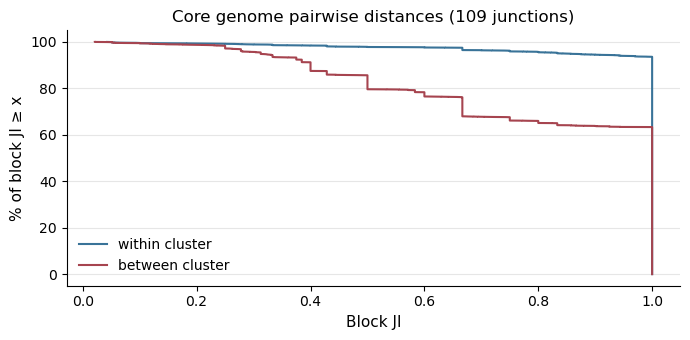

In [15]:
# only look at junctions with at least two cluster when comparing within and between dist, (we want blue to be high, red to be low)
cluster_df = pd.read_csv(f"../results/consensus_analysis/cluster_maps_0_001.csv")
plot_all_junctions_pairwise_distances(                                                                                                                                                                    
      block_edge_dist[block_edge_dist['junction_name'].isin(clustering_exists)],
      distance_col='block_ji_dist',                                                                                                                                                                                  
      cumulative=True,
      percentage=True,
      log_x=False,
      cluster_df=cluster_df,
      vline=None,
      xlabel="Block JI",
      ylabel="% of block JI ≥ x",
  )

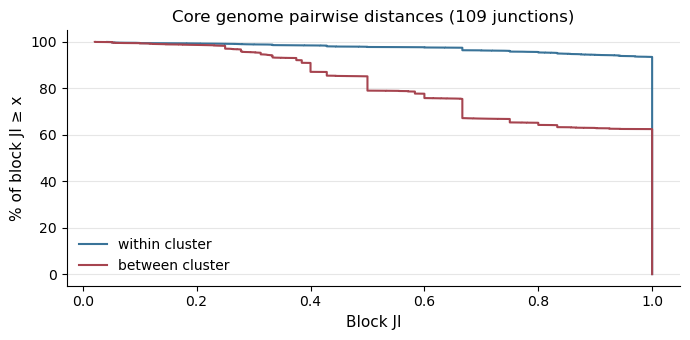

In [17]:
cluster_df = pd.read_csv(f"../results/consensus_analysis/cluster_maps_0_003.csv")
plot_all_junctions_pairwise_distances(                                                                                                                                                                    
      block_edge_dist[block_edge_dist['junction_name'].isin(clustering_exists)],
      distance_col='block_ji_dist',                                                                                                                                                                                  
      cumulative=True,
      percentage=True,
      log_x=False,
      cluster_df=cluster_df,
      vline=None,
      xlabel="Block JI",
      ylabel="% of block JI ≥ x",
  )

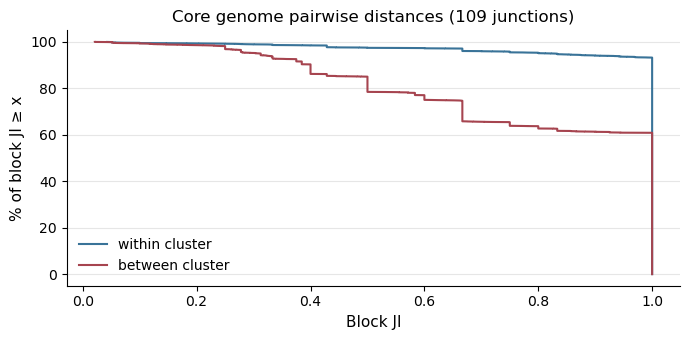

In [18]:
cluster_df = pd.read_csv(f"../results/consensus_analysis/cluster_maps_0_005.csv")
plot_all_junctions_pairwise_distances(                                                                                                                                                                    
      block_edge_dist[block_edge_dist['junction_name'].isin(clustering_exists)],
      distance_col='block_ji_dist',                                                                                                                                                                                  
      cumulative=True,
      percentage=True,
      log_x=False,
      cluster_df=cluster_df,
      vline=None,
      xlabel="Block JI",
      ylabel="% of block JI ≥ x",
  )

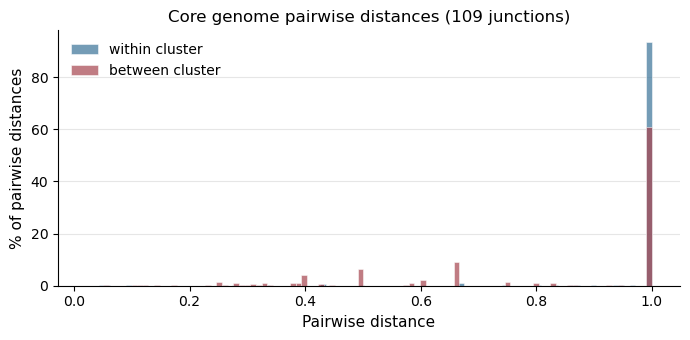

In [19]:
plot_all_junctions_pairwise_distances(                                                                                                                                                                    
      block_edge_dist[block_edge_dist['junction_name'].isin(cluster_df[cluster_df['n_clusters'] > 1].junction_name.to_list())],
      distance_col='block_ji_dist',                                                                                                                                                                                  
      cumulative=False,
      percentage=True,
      log_x=False,
      cluster_df=cluster_df,
      vline=None,
      xlabel="Pairwise distance",
      ylabel="% of pairwise distances",
  )

## 

